In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('dark_background')
sns.set_palette("husl")

matches = pd.read_csv('matches_clean.csv')
deliveries = pd.read_csv('deliveries_clean.csv')

print("Clean data loaded")
print(f"Matches: {matches.shape}")
print(f"Deliveries: {deliveries.shape}")

Clean data loaded
Matches: (1095, 22)
Deliveries: (260920, 17)


In [7]:
import os
os.makedirs('charts', exist_ok=True)
print("Charts folder ready")
print(f"Current working directory: {os.getcwd()}")

Charts folder ready
Current working directory: d:\hackaton,projects\ipl-analytics


C:\Users\ASUS\AppData\Local\Temp\ipykernel_16100\355001436.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=team_wins, x='wins', y='team', palette='rocket')


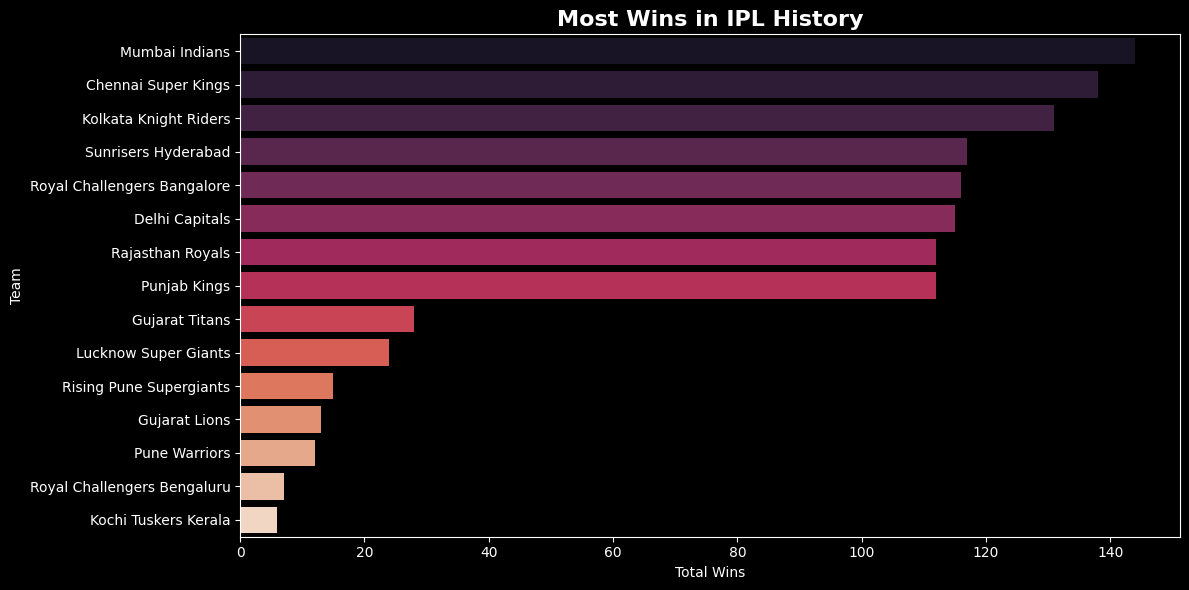

                           team  wins
0                Mumbai Indians   144
1           Chennai Super Kings   138
2         Kolkata Knight Riders   131
3           Sunrisers Hyderabad   117
4   Royal Challengers Bangalore   116
5                Delhi Capitals   115
6              Rajasthan Royals   112
7                  Punjab Kings   112
8                Gujarat Titans    28
9          Lucknow Super Giants    24
10      Rising Pune Supergiants    15
11                Gujarat Lions    13
12                Pune Warriors    12
13  Royal Challengers Bengaluru     7
14         Kochi Tuskers Kerala     6


In [12]:
team_wins = matches['winner'].value_counts().reset_index()
team_wins.columns = ['team', 'wins']
team_wins = team_wins[team_wins['team'].notna()]

plt.figure(figsize=(12, 6))
sns.barplot(data=team_wins, x='wins', y='team', palette='rocket')
plt.title('Most Wins in IPL History', fontsize=16, fontweight='bold')
plt.xlabel('Total Wins')
plt.ylabel('Team')
plt.tight_layout()
plt.savefig('charts/02_team_wins.png', dpi=150)
plt.show()

print(team_wins)

Toss Impact on Match Result:
Won toss AND won match: 50.6%
Won toss but LOST match: 49.4%


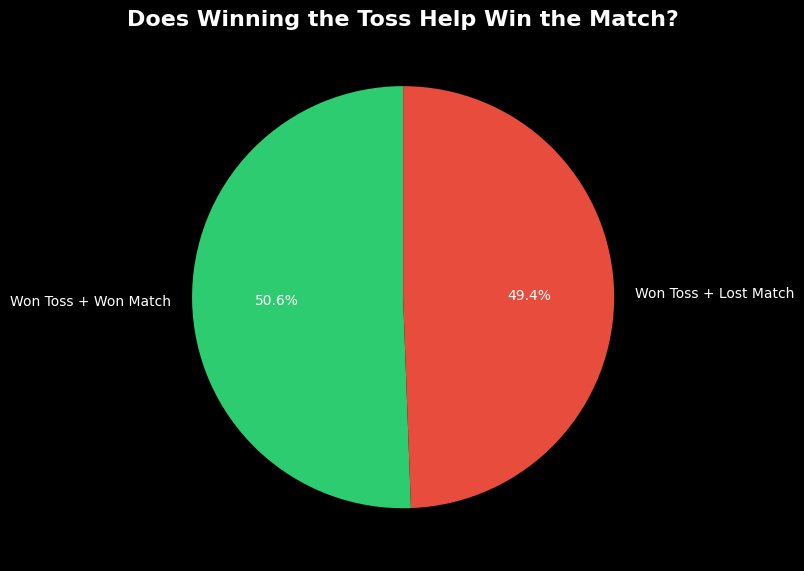

In [11]:
# Did winning toss help win the match?
matches['toss_match_winner'] = matches['toss_winner'] == matches['winner']

toss_win_rate = matches['toss_match_winner'].value_counts(normalize=True) * 100

print("Toss Impact on Match Result:")
print(f"Won toss AND won match: {toss_win_rate[True]:.1f}%")
print(f"Won toss but LOST match: {toss_win_rate[False]:.1f}%")

# Visualize
labels = ['Won Toss + Won Match', 'Won Toss + Lost Match']
sizes = [toss_win_rate[True], toss_win_rate[False]]
colors = ['#2ecc71', '#e74c3c']

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Does Winning the Toss Help Win the Match?', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/03_toss_impact.png', dpi=150)
plt.show()

In [ ]:
toss_decision = matches['toss_decision'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=toss_decision.index, y=toss_decision.values, palette='coolwarm')
plt.title('Toss Decision — Bat or Field First?', fontsize=16, fontweight='bold')
plt.xlabel('Decision')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('charts/04_toss_decision.png', dpi=150)
plt.show()

print(toss_decision)

In [ ]:
toss_by_season = matches.groupby(['season', 'toss_decision']).size().unstack(fill_value=0)

toss_by_season.plot(kind='bar', figsize=(14, 6), colormap='coolwarm')
plt.title('Toss Decision Trend by Season', fontsize=16, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Count')
plt.legend(title='Decision')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('charts/05_toss_decision_by_season.png', dpi=150)
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16100\2441630302.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_venues, x='matches_hosted', y='venue', palette='magma')


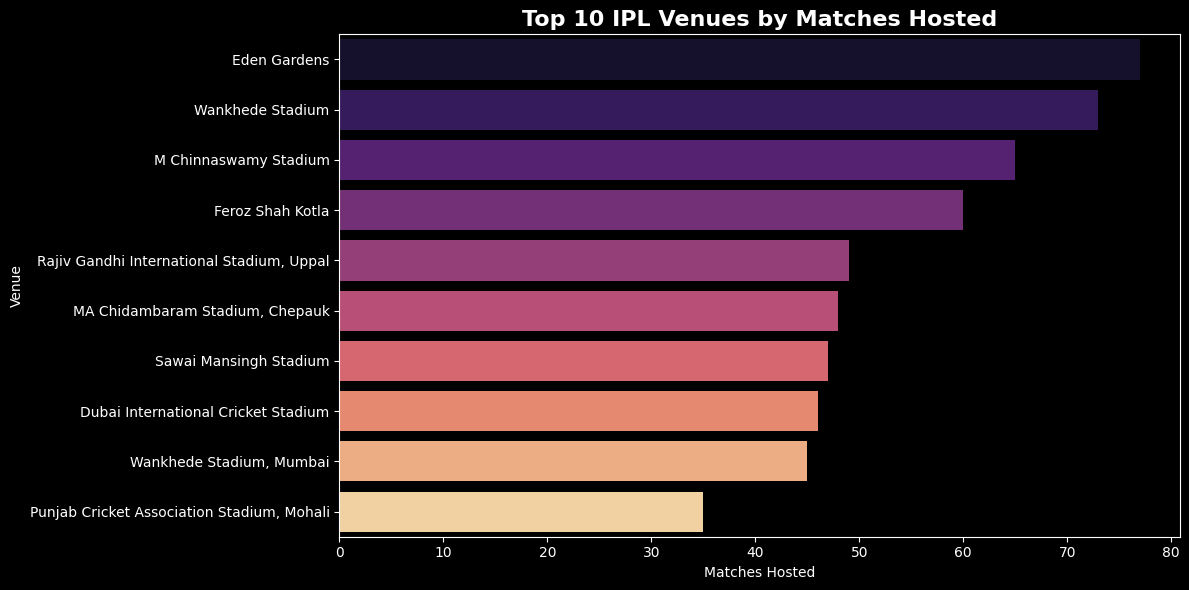

In [10]:
top_venues = matches['venue'].value_counts().head(10).reset_index()
top_venues.columns = ['venue', 'matches_hosted']

plt.figure(figsize=(12, 6))
sns.barplot(data=top_venues, x='matches_hosted', y='venue', palette='magma')
plt.title('Top 10 IPL Venues by Matches Hosted', fontsize=16, fontweight='bold')
plt.xlabel('Matches Hosted')
plt.ylabel('Venue')
plt.tight_layout()
plt.savefig('charts/06_top_venues.png', dpi=150)
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16100\843570019.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=win_type.index, y=win_type.values, palette='Set2')


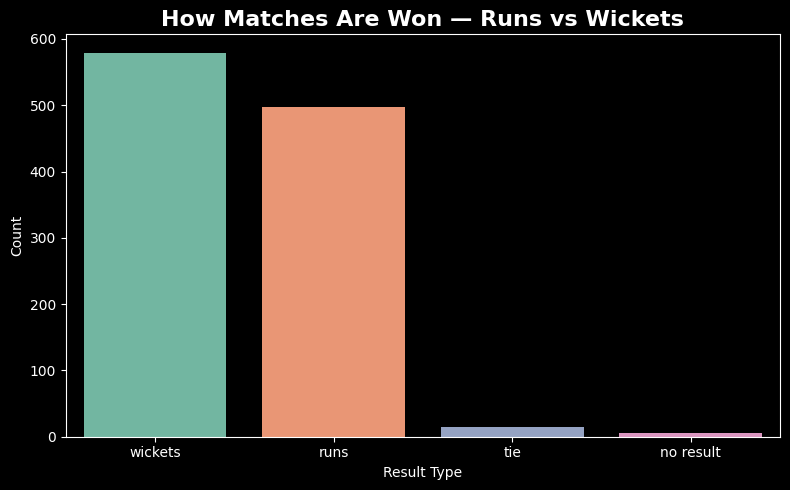

result
wickets      578
runs         498
tie           14
no result      5
Name: count, dtype: int64


In [8]:
win_type = matches['result'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=win_type.index, y=win_type.values, palette='Set2')
plt.title('How Matches Are Won — Runs vs Wickets', fontsize=16, fontweight='bold')
plt.xlabel('Result Type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('charts/07_win_type.png', dpi=150)
plt.show()

print(win_type)

Win by Runs Statistics:
  Average margin: 30.1 runs
  Biggest win: 146 runs
  Smallest win: 1 runs

Win by Wickets Statistics:
  Average margin: 6.2 wickets
  Biggest win: 10 wickets
  Smallest win: 1 wickets


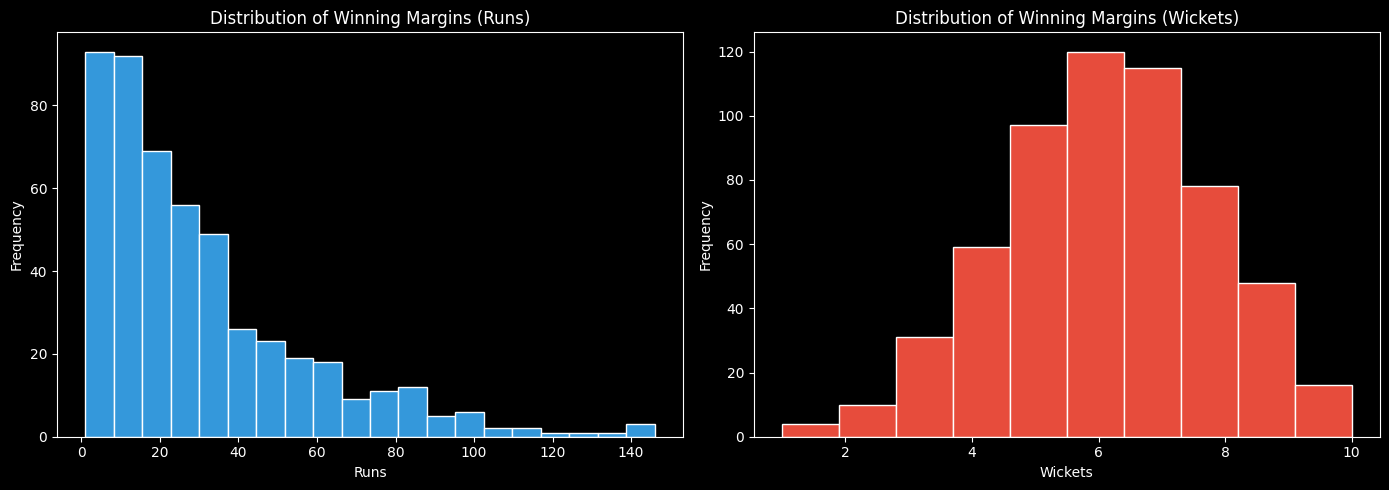

In [9]:
# Separate wins by runs vs wickets
wins_by_runs = matches[matches['result'] == 'runs']['result_margin']
wins_by_wickets = matches[matches['result'] == 'wickets']['result_margin']

print("Win by Runs Statistics:")
print(f"  Average margin: {wins_by_runs.mean():.1f} runs")
print(f"  Biggest win: {wins_by_runs.max():.0f} runs")
print(f"  Smallest win: {wins_by_runs.min():.0f} runs")
print()
print("Win by Wickets Statistics:")
print(f"  Average margin: {wins_by_wickets.mean():.1f} wickets")
print(f"  Biggest win: {wins_by_wickets.max():.0f} wickets")
print(f"  Smallest win: {wins_by_wickets.min():.0f} wickets")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(wins_by_runs, bins=20, color='#3498db', edgecolor='white')
axes[0].set_title('Distribution of Winning Margins (Runs)')
axes[0].set_xlabel('Runs')
axes[0].set_ylabel('Frequency')

axes[1].hist(wins_by_wickets, bins=10, color='#e74c3c', edgecolor='white')
axes[1].set_title('Distribution of Winning Margins (Wickets)')
axes[1].set_xlabel('Wickets')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('charts/08_winning_margins.png', dpi=150)
plt.show()